In [ ]:
"""
Amaç:
    Burdaki amaç customer_churn_dataset-testing-master.csv datasetinde veri incelemesi ve makine öğrenmesi modelleri uygulamak ve hangi modelin daha iyi çıktı verdiğini görmek olacakatır
Plan/Program:
    1- kütüphaneleri içeriye aktarmak
    2-veri seti yüklemek
    3-boş değer var mı bakmak varsa silmek veya doldurmak
    4-encode işlemlerini yapma (kategorik değerleri sayısal değerlere çevirme)
    5-korelasyon anlizi yapmak 
    6-korelasyon analizine göre ilişkilerine barplot ile bakmak
    7-X ve y değişkenleri ayırmak
    8-train test ve validation değerlerine ayırmak
    9-Standardization işlemi yaparak ölçeklendirme 
    10-model eğitimini yapmak
    11-eğitilen değerlerin scorelarına bakmak
    decision tree de overfitting var mı diye bakmak
    12 - modeli daha iyi hale getirebilir miyiz sorusuna cevap arıyoruz(Hyperparametet Tuning)
    13-Grid search kullanarak hiperparametre ayarlaması yapmak
    14-Model karşılaştırması yapmak 
    15-hangi modelin daha iyi sonuç verdiğini görmek 



"""

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


In [3]:
df = pd.read_csv("customer_churn_dataset-testing-master.csv")


In [4]:
df.head(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0


In [ ]:
df.drop("CustomerID",axis = 1,inplace=True)# gereksiz kolonu veri setinden silme işlemi
df.head()


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
df.info()# burada veri setimiz hakkında bilgilendirme mesajı almaktayız

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  str  
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  str  
 7   Contract Length    64374 non-null  str  
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int64(8), str(3)
memory usage: 5.4 MB


In [ ]:
df.isnull().sum()# burada ise eksik ya da nan değer var mı bakmak istiyoruz

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [ ]:
df.describe()# burda ise sayısal sütunların matematiksel ortalama standart sapma min max gibi değerlerine bakmaktaız

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
df["Churn"].value_counts()# burda ise bir yanlılık(bias) var mı diye baktım dengeli mi diye dengeli olduğunu gördüm

Churn
0    33881
1    30493
Name: count, dtype: int64

In [ ]:
sayisal_sutunlar = df.select_dtypes(include=["int", "float"]).columns.to_list()
sayisal_sutunlar# burada ise sayısal sütunları çektim belki işime yara diye de yaramadı bilgi olsun diye koydum:D

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction',
 'Churn']

In [11]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
df.shape# burda ise kaç sütun kaç satır var ona baktım

(64374, 11)

In [50]:
df.duplicated().sum()# burda ise tekrar eden var mı diye bakıyorum

np.int64(0)

In [ ]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])# burda label encoder kullanarak Gender kolonunu 0 ve 1 haline getiriyorum makine öğrenmesi algoritmasına sokabilmek için
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,Basic,Monthly,598,9,1
1,41,0,28,28,7,13,Standard,Monthly,584,20,0
2,47,1,27,10,2,29,Premium,Annual,757,21,0
3,35,1,9,12,5,17,Premium,Quarterly,232,18,0
4,53,0,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
df["Subscription Type"].value_counts()# burda da değer sayılarına bakmaktayım


Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

In [16]:
df["Contract Length"].value_counts()

Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64

In [ ]:
ordinal = OrdinalEncoder(
    categories=[
        ["Basic", "Standard", "Premium"],
        ["Monthly", "Quarterly", "Annual"]
    ]
)

df[["Subscription Type", "Contract Length"]] = ordinal.fit_transform(
    df[["Subscription Type", "Contract Length"]]
).astype(int)
df.head()
# ordinal encoder yaparak sırasıyla 0-1-2 alıyorum çünkü aralarında bir sıralı ilişki bulunuyor aksi takdirde one hot encoding yapardım

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,0,598,9,1
1,41,0,28,28,7,13,1,0,584,20,0
2,47,1,27,10,2,29,2,2,757,21,0
3,35,1,9,12,5,17,2,1,232,18,0
4,53,0,58,24,9,2,1,2,533,18,0


In [ ]:
corr = df.corr(numeric_only=True)

print(corr)# burda korelasyonlarına bakıyorum ama burdan bir şey anlaşılmıyor  o yüzden altında daha anlaşılır olan heatmap çizdiriyrum

                        Age    Gender    Tenure  Usage Frequency  \
Age                1.000000  0.001800 -0.007763        -0.038331   
Gender             0.001800  1.000000  0.029418        -0.006907   
Tenure            -0.007763  0.029418  1.000000         0.023485   
Usage Frequency   -0.038331 -0.006907  0.023485         1.000000   
Support Calls      0.005014  0.035418  0.060065        -0.014072   
Payment Delay     -0.016132 -0.058578  0.055963         0.031132   
Subscription Type -0.001730  0.003434 -0.000392        -0.000010   
Contract Length   -0.001181  0.029300  0.002505        -0.012548   
Total Spend        0.006490  0.029337  0.009474         0.001527   
Last Interaction  -0.000148 -0.000472  0.005770        -0.009192   
Churn              0.063457 -0.164549  0.195327        -0.115098   

                   Support Calls  Payment Delay  Subscription Type  \
Age                     0.005014      -0.016132          -0.001730   
Gender                  0.035418      -0.05

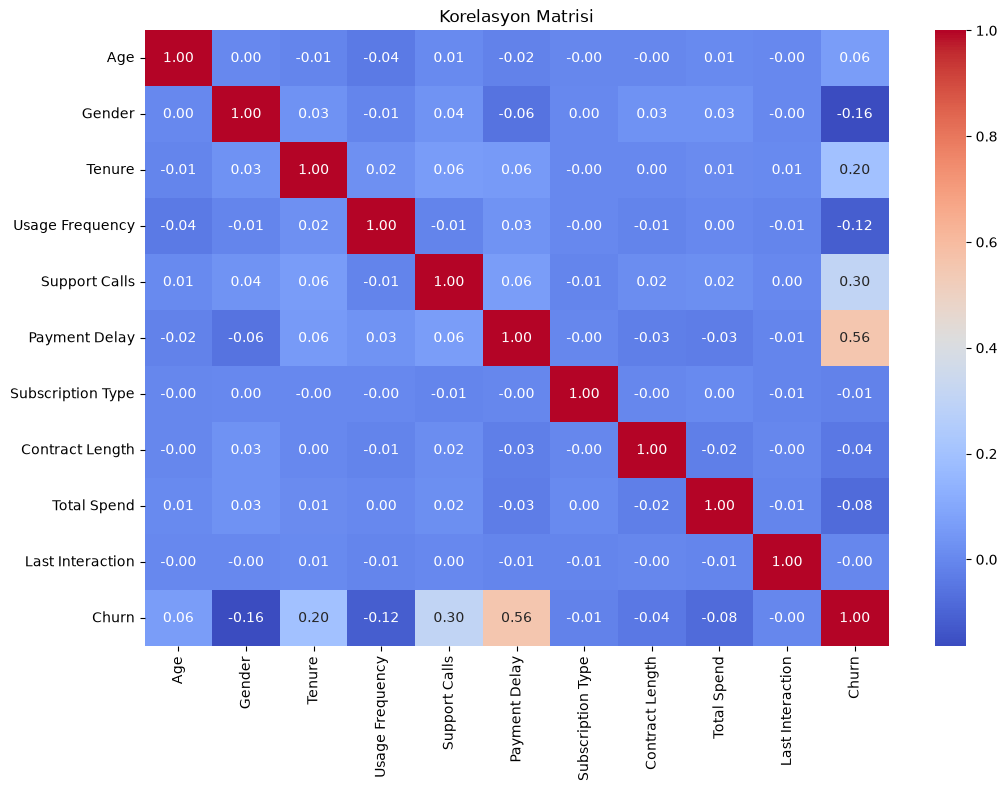

In [ ]:

plt.figure(figsize=(12, 8))# korelasyonu yüksek olan birbiriyle daha çok ilişkili bizim hedefimiz Churn olduğu için onunla neler ilişkili akmak daha mantıklı geldi bana

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasyon Matrisi")
plt.show()

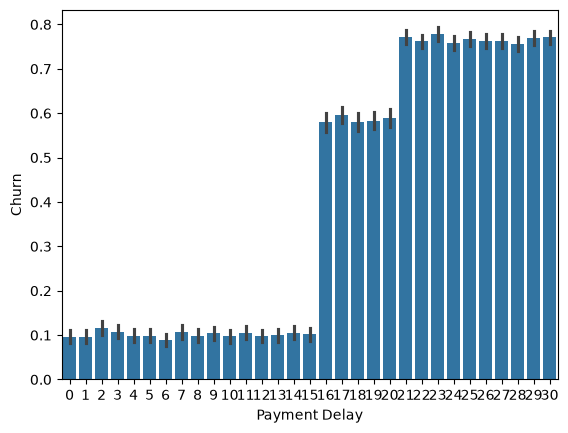

In [ ]:
plt.Figure(figsize=(10,8))
sns.barplot(x = df["Payment Delay"],y = df["Churn"])# burda ise bar plot çizimi yaparak pozitif bir kolrelasyon görmek mümkün
plt.show()

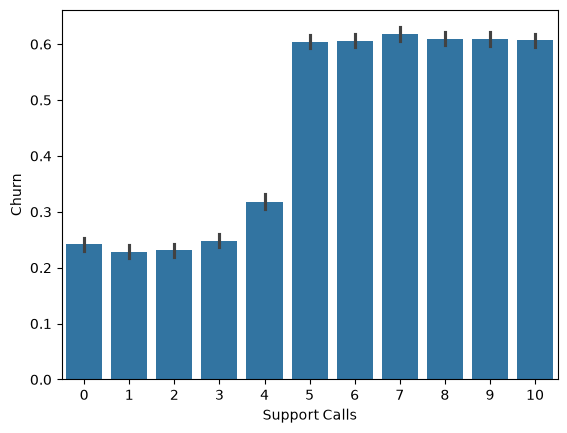

In [21]:
plt.Figure(figsize=(10,8))
sns.barplot(x = df["Support Calls"],y = df["Churn"])
plt.show()

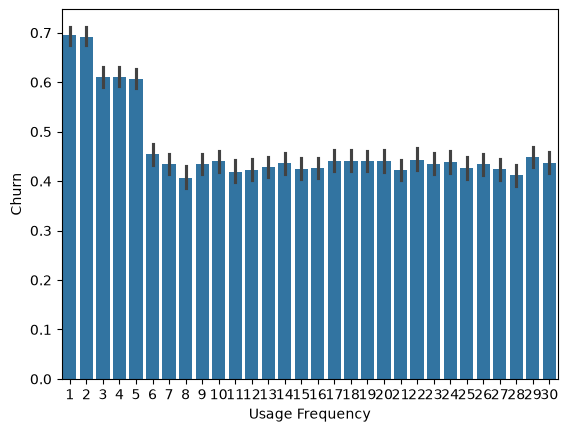

In [22]:
plt.Figure(figsize=(10,8))
sns.barplot(x = df["Usage Frequency"],y = df["Churn"])
plt.show()

In [ ]:
X = df.drop("Churn",axis=1)# X ve y değişkenlerini ayırmak 
y = df["Churn"]

In [ ]:
# train test ve validasyon olarak ayırma işlemi satratify = y kullanmamın sebebi daha dengeli olsun diye
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

X_train: (38624, 10)
X_val: (12875, 10)
X_test: (12875, 10)


In [ ]:
scaler = StandardScaler()# ölçeklme işlemi ortalamayı  std yi  yapmak için 

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(38624, 10)
(12875, 10)
(12875, 10)


In [ ]:
# burda da model eğitimimizi yapmaktayız
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)
y_val_pred_log = log_model.predict(X_val_scaled)
log_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_log
)

print("Logistic Regression Validation Accuracy:",
      log_val_accuracy)

Logistic Regression Validation Accuracy: 0.8311456310679611


In [27]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

y_val_pred_knn = knn_model.predict(X_val_scaled)

knn_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_knn
)

print("KNN Validation Accuracy:",
      knn_val_accuracy)

KNN Validation Accuracy: 0.9073398058252428


In [28]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_val_pred_dt = dt_model.predict(X_val)

In [51]:
print("Logistic Regression Validation")
print(classification_report(y_val, y_val_pred_log))

print(" KNN - Validation ")
print(classification_report(y_val, y_val_pred_knn))

print(" Decision Tree - Validation")
print(classification_report(y_val, y_val_pred_dt))

Logistic Regression Validation
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6776
           1       0.82      0.83      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

 KNN - Validation 
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      6776
           1       0.90      0.96      0.93      6099

    accuracy                           0.93     12875
   macro avg       0.93      0.93      0.93     12875
weighted avg       0.93      0.93      0.93     12875

 Decision Tree - Validation
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12

In [ ]:
# burada ise Grid search cv kullanarak hiper parametre ayarlaması yapmaktayım
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15],# max ağaç derinliği
    "min_samples_split": [2, 5, 10, 20],# 
    "min_samples_leaf": [1, 2, 5, 10]# 
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [ ]:
# En iyi parametreleri buluyoruz
print("En iyi parametreler:")
print(grid_search.best_params_)

print("\nEn iyi CV F1 skoru:")
print(grid_search.best_score_)

En iyi parametreler:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

En iyi CV F1 skoru:
0.9973503049210276


In [ ]:
# burda acaba decision tree overfitting yapar mıyı araştırıyorum
print(X.columns)

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction'],
      dtype='str')


In [35]:
print(
    df.corr(numeric_only=True)["Churn"]
    .sort_values(ascending=False)
)

Churn                1.000000
Payment Delay        0.557386
Support Calls        0.304631
Tenure               0.195327
Age                  0.063457
Last Interaction    -0.002818
Subscription Type   -0.014555
Contract Length     -0.044830
Total Spend         -0.078867
Usage Frequency     -0.115098
Gender              -0.164549
Name: Churn, dtype: float64


In [36]:
best_dt = grid_search.best_estimator_

print("Tree depth:", best_dt.get_depth())
print("Number of leaves:", best_dt.get_n_leaves())

Tree depth: 13
Number of leaves: 124


In [ ]:
# burada validation ve eğitim sonuçlarına bakıyorum ve overfitting olmadığını decision tree modelinin çok iyi çalıştığını söylemek mümkün
from sklearn.metrics import f1_score

y_train_pred_dt = best_dt.predict(X_train)
y_val_pred_dt = best_dt.predict(X_val)

train_f1_dt = f1_score(y_train, y_train_pred_dt)
val_f1_dt = f1_score(y_val, y_val_pred_dt)

print(f"Training F1   : {train_f1_dt:.4f}")
print(f"CV F1         : {grid_search.best_score_:.4f}")
print(f"Validation F1 : {val_f1_dt:.4f}")

Training F1   : 1.0000
CV F1         : 0.9974
Validation F1 : 0.9979


In [38]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

log_grid = GridSearchCV(
    estimator=log_model,
    param_grid=log_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

log_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

In [41]:
print("Logistic Regression En İyi Parametreler:")
print(log_grid.best_params_)

print("\nLogistic Regression En İyi CV F1:")
print(log_grid.best_score_)
best_log = log_grid.best_estimator_
y_val_pred_log = best_log.predict(X_val_scaled)

print("=== Tuned Logistic Regression - Validation ===")
print(classification_report(y_val, y_val_pred_log))

Logistic Regression En İyi Parametreler:
{'C': 0.01, 'solver': 'liblinear'}

Logistic Regression En İyi CV F1:
0.8173764462868089
=== Tuned Logistic Regression - Validation ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6776
           1       0.82      0.83      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [42]:
knn_model = KNeighborsClassifier()

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)
print("KNN En İyi Parametreler:")
print(knn_grid.best_params_)

print("\nKNN En İyi CV F1:")
print(knn_grid.best_score_)
best_knn = knn_grid.best_estimator_
y_val_pred_knn = best_knn.predict(X_val_scaled)
print("=== Tuned KNN - Validation ===")
print(classification_report(y_val, y_val_pred_knn))

KNN En İyi Parametreler:
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}

KNN En İyi CV F1:
0.9240282034212841
=== Tuned KNN - Validation ===
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      6776
           1       0.90      0.96      0.93      6099

    accuracy                           0.93     12875
   macro avg       0.93      0.93      0.93     12875
weighted avg       0.93      0.93      0.93     12875



Decision Tree Test Sonuçları
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



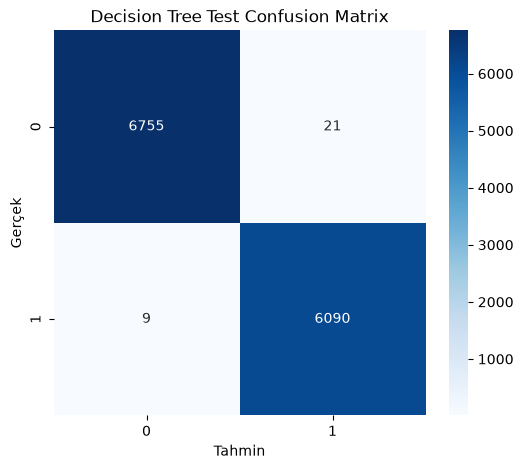

In [53]:
y_test_pred = best_dt.predict(X_test)
print("Decision Tree Test Sonuçları")
print(classification_report(y_test, y_test_pred))
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Decision Tree Test Confusion Matrix")

plt.show()

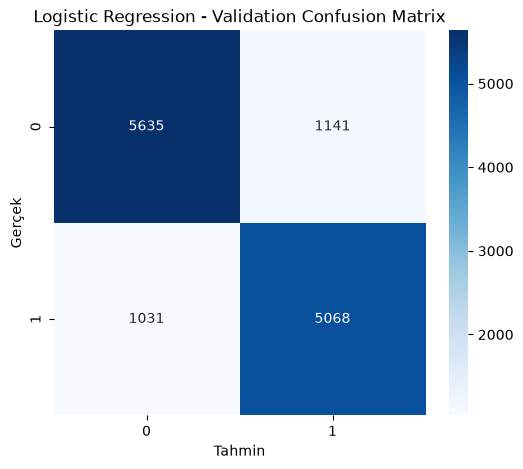

In [ ]:
# Logistic Regression
cm_log = confusion_matrix(y_val, y_val_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()



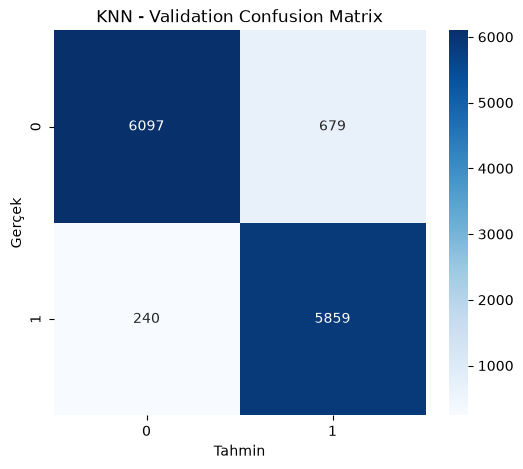

In [ ]:
cm_knn = confusion_matrix(y_val, y_val_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("KNN - Validation Confusion Matrix")
plt.show()

In [54]:
# Decision Tree algoritmasının daha iyi bir sonuç verdiğini gözlemledim 
# KNN ve Logistic regresyon da iyi sonuç gösterdi ama Decision tree modeli gözle görülebilir bir şekilde iyi bir model diğer ikisine kıyasla 
# scorlara bakarak bnları görmek mümkündür